# Easy21 — Monte Carlo Control, TD(λ), and Linear Function Approximation

An implementation of the "Easy21" assignment from David Silver's [Reinforcement Learning course](https://www.davidsilver.uk/teaching/)
(UCL) — a simplified Blackjack variant used to compare three families of RL algorithm on the same
environment: tabular Monte Carlo control, tabular Sarsa(λ), and Sarsa(λ) with linear function
approximation over a coarse-coded feature space.

**Rules:** Each draw is a black card (values 1–10, uniform) with probability 2/3, or a red card
(values −1 to −10, uniform) with probability 1/3. The dealer starts with one black card and sticks on
any sum ≥ 17; the player starts with one black card and may `hit` or `stick`. Going below 1 or above
21 is a bust (loss). Otherwise the higher final sum wins; a tie is a draw.

In [1]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [2]:
class Easy21:
    def draw_black(self):
        return np.random.randint(1, 11)

    def draw_red(self):
        return -np.random.randint(1, 11)

    def draw_card(self):
        if np.random.random() < 1 / 3:
            return self.draw_red()
        else:
            return self.draw_black()

    def init(self):
        self.player = self.draw_black()
        self.dealer = self.draw_black()
        return self.player, self.dealer

    def step(self, s, a):
        player, dealer = s

        if a == 'hit':
            player += self.draw_card()
            if player > 21 or player < 1:
                return (player, dealer), -1, True
            else:
                return (player, dealer), 0, False

        elif a == 'stick':
            while dealer < 17:
                dealer += self.draw_card()

            if dealer > 21 or dealer < 1:
                return (player, dealer), 1, True
            elif dealer > player:
                return (player, dealer), -1, True
            elif dealer < player:
                return (player, dealer), 1, True
            else:
                return (player, dealer), 0, True


## Monte Carlo Control

Every-visit Monte Carlo control with a GLIE (Greedy in the Limit with Infinite Exploration) policy:
$\varepsilon_t = N_0 / (N_0 + N(S_t))$, so exploration decays as a state is visited more often, and the
step size $\alpha = 1/N(S_t, A_t)$ decays with the state-action visit count.

In [3]:
class MonteCarloControl:
    HIT = 'hit'
    STICK = 'stick'

    def __init__(self, N0=100):
        self.N_0 = N0
        self.Q = defaultdict(float)
        self.N_sa = defaultdict(int)
        self.N_s = defaultdict(int)
        self.env = Easy21()
        self.gamma = 1

    def epsilon_policy(self, state):
        epsilon = self.N_0 / (self.N_0 + self.N_s[state])
        if np.random.random() < epsilon:
            return np.random.choice([self.STICK, self.HIT])
        else:
            if self.Q[(state, self.STICK)] > self.Q[(state, self.HIT)]:
                return self.STICK
            else:
                return self.HIT

    def create_episode(self):
        episode = []
        state = self.env.init()
        done = False

        while not done:
            self.N_s[state] += 1
            action = self.epsilon_policy(state)
            next_state, reward, done = self.env.step(state, action)
            episode.append((state, action, reward))
            state = next_state

        return episode

    def update(self, episode):
        """Every-visit Monte Carlo update over one completed episode."""
        G = 0
        for state, action, reward in reversed(episode):
            G = reward + self.gamma * G
            self.N_sa[(state, action)] += 1
            alpha = 1 / self.N_sa[(state, action)]
            self.Q[(state, action)] += alpha * (G - self.Q[(state, action)])

    def train(self, num_episodes):
        for _ in range(num_episodes):
            episode = self.create_episode()
            self.update(episode)


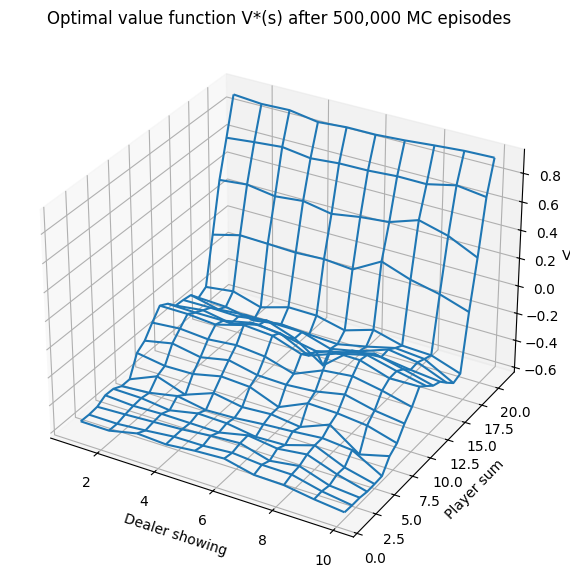

In [4]:
mc = MonteCarloControl()
mc.train(500000)

dealer_range = range(1, 11)
player_range = range(1, 22)

X, Y = np.meshgrid(dealer_range, player_range)
Z = np.zeros_like(X, dtype=float)

for i, player in enumerate(player_range):
    for j, dealer in enumerate(dealer_range):
        state = (player, dealer)
        Z[i, j] = max(mc.Q[(state, 'hit')], mc.Q[(state, 'stick')])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_wireframe(X, Y, Z)
ax.set_xlabel('Dealer showing')
ax.set_ylabel('Player sum')
ax.set_zlabel('V(s)')
ax.set_title('Optimal value function V*(s) after 500,000 MC episodes')
plt.show()


## TD Learning: Sarsa(λ)

Tabular Sarsa(λ) with backward-view eligibility traces, using the same GLIE policy and step-size
schedule as Monte Carlo control above. We evaluate against $Q^*$ estimated by running Monte Carlo
control for 1,000,000 episodes — that same $Q^*$ is reused for the linear function approximation
section below, so both methods are compared against one consistent ground truth rather than two
separately-sampled estimates.

In [5]:
class SarsaLambda:
    HIT = 'hit'
    STICK = 'stick'

    def __init__(self, N0=100, lam=0):
        self.N_0 = N0
        self.Q = defaultdict(float)
        self.N_sa = defaultdict(int)
        self.N_s = defaultdict(int)
        self.env = Easy21()
        self.gamma = 1
        self.lam = lam

    def epsilon_policy(self, state):
        epsilon = self.N_0 / (self.N_0 + self.N_s[state])
        if np.random.random() < epsilon:
            return np.random.choice([self.STICK, self.HIT])
        else:
            if self.Q[(state, self.STICK)] > self.Q[(state, self.HIT)]:
                return self.STICK
            else:
                return self.HIT

    def run_episode(self):
        E = defaultdict(float)
        state = self.env.init()
        action = self.epsilon_policy(state)
        done = False

        while not done:
            self.N_s[state] += 1
            next_state, reward, done = self.env.step(state, action)

            if not done:
                next_action = self.epsilon_policy(next_state)
                delta = reward + self.gamma * self.Q[(next_state, next_action)] - self.Q[(state, action)]
            else:
                delta = reward - self.Q[(state, action)]

            self.N_sa[(state, action)] += 1
            E[(state, action)] += 1

            for sa in E:
                alpha = 1 / self.N_sa[sa] if self.N_sa[sa] > 0 else 1
                self.Q[sa] += alpha * delta * E[sa]
                E[sa] *= self.gamma * self.lam

            if not done:
                state, action = next_state, next_action

    def train(self, num_episodes):
        for _ in range(num_episodes):
            self.run_episode()


In [6]:
def compute_mse(Q, Q_star):
    mse = 0
    count = 0
    for player in range(1, 22):
        for dealer in range(1, 11):
            for a in ['hit', 'stick']:
                sa = ((player, dealer), a)
                mse += (Q[sa] - Q_star[sa]) ** 2
                count += 1
    return mse / count


def learning_curve(lam, Q_star, num_episodes=1000):
    td = SarsaLambda(lam=lam)
    mses = []
    for _ in range(num_episodes):
        td.run_episode()
        mses.append(compute_mse(td.Q, Q_star))
    return mses


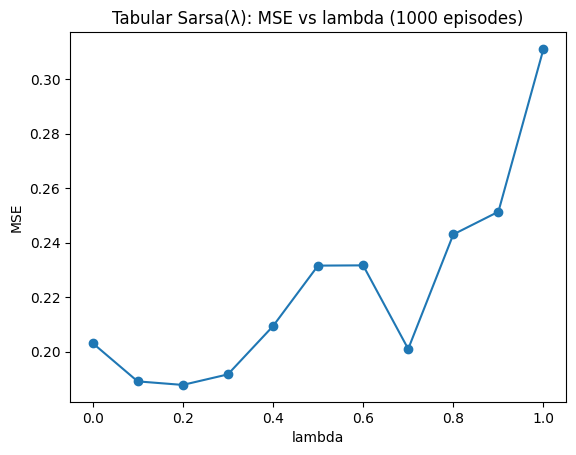

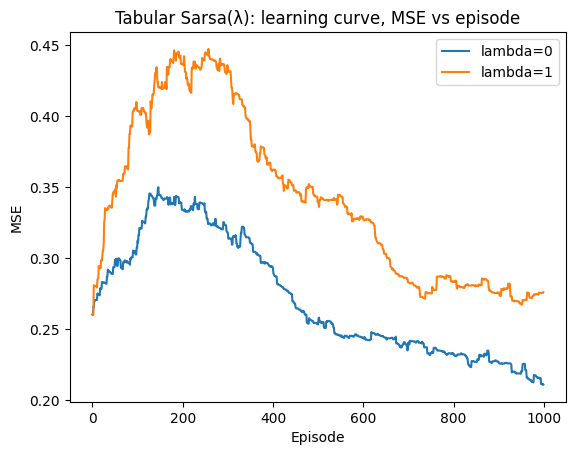

In [7]:
mc_star = MonteCarloControl()
mc_star.train(1000000)
Q_star = mc_star.Q

lambdas = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
mse_results = []

for lam in lambdas:
    td = SarsaLambda(lam=lam)
    td.train(1000)
    mse_results.append(compute_mse(td.Q, Q_star))

plt.plot(lambdas, mse_results, marker='o')
plt.xlabel('lambda')
plt.ylabel('MSE')
plt.title('Tabular Sarsa(λ): MSE vs lambda (1000 episodes)')
plt.show()

curve_0 = learning_curve(0, Q_star)
curve_1 = learning_curve(1, Q_star)

plt.plot(range(1000), curve_0, label='lambda=0')
plt.plot(range(1000), curve_1, label='lambda=1')
plt.xlabel('Episode')
plt.ylabel('MSE')
plt.legend()
plt.title('Tabular Sarsa(λ): learning curve, MSE vs episode')
plt.show()


## Linear Function Approximation: Sarsa(λ) with Coarse Coding

We replace the table with 36 binary features (3 overlapping dealer intervals × 6 overlapping player
intervals × 2 actions) and a single linear weight vector $\theta$, updated via Sarsa(λ) with
accumulating eligibility traces over the feature weights rather than over individual states.

We reuse the same $Q^*$ computed above rather than retraining another 1,000,000-episode Monte Carlo
run, so all three methods in this notebook are compared against one shared ground truth.

In [8]:
class LinearSarsaLambda:
    HIT = 'hit'
    STICK = 'stick'

    def __init__(self, lam=0):
        self.dealer = [(1, 4), (4, 7), (7, 10)]
        self.player = [(1, 6), (4, 9), (7, 12), (10, 15), (13, 18), (16, 21)]
        self.action = ['hit', 'stick']

        self.epsilon = 0.05
        self.alpha = 0.01
        self.lam = lam

        self.features = 36
        self.theta = np.zeros(self.features)

        self.env = Easy21()
        self.gamma = 1

    def encode(self, s, a):
        """Active (overlapping) coarse-coding feature indices for (state, action)."""
        p, d = s
        active_features = []

        for i in range(len(self.dealer)):
            if self.dealer[i][0] <= d <= self.dealer[i][1]:
                for j in range(len(self.player)):
                    if self.player[j][0] <= p <= self.player[j][1]:
                        if a == self.action[0]:
                            active_features.append(i * 1 + j * 3)
                        elif a == self.action[1]:
                            active_features.append(i * 1 + j * 3 + 18)

        return active_features

    def Q_value(self, phi):
        """Q_theta(s, a) = sum of theta[idx] over active feature indices idx in phi."""
        total = 0.0
        for idx in phi:
            total += self.theta[idx]
        return total

    def epsilon_greedy(self, state):
        if np.random.random() < self.epsilon:
            return np.random.choice([self.STICK, self.HIT])
        else:
            q_hit = self.Q_value(self.encode(state, self.HIT))
            q_stick = self.Q_value(self.encode(state, self.STICK))
            if q_stick > q_hit:
                return self.STICK
            else:
                return self.HIT

    def run_episode(self):
        E = np.zeros(self.features)

        state = self.env.init()
        action = self.epsilon_greedy(state)
        phi = self.encode(state, action)
        done = False

        while not done:
            next_state, reward, done = self.env.step(state, action)

            if not done:
                next_action = self.epsilon_greedy(next_state)
                phi_next = self.encode(next_state, next_action)
                delta = reward + self.gamma * self.Q_value(phi_next) - self.Q_value(phi)
            else:
                delta = reward - self.Q_value(phi)

            for idx in phi:
                E[idx] += 1

            self.theta += self.alpha * delta * E
            E *= self.gamma * self.lam

            if not done:
                state, action = next_state, next_action
                phi = phi_next

    def train(self, num_episodes):
        for _ in range(num_episodes):
            self.run_episode()


In [9]:
def compute_mse_linear(sarsa, Q_star):
    mse = 0
    count = 0
    for player in range(1, 22):
        for dealer in range(1, 11):
            for a in ['hit', 'stick']:
                state = (player, dealer)
                phi = sarsa.encode(state, a)
                Q = sarsa.Q_value(phi)
                mse += (Q - Q_star[(state, a)]) ** 2
                count += 1
    return mse / count


def learning_curve_linear(lam, Q_star, num_episodes=1000):
    sarsa = LinearSarsaLambda(lam=lam)
    mses = []
    for _ in range(num_episodes):
        sarsa.run_episode()
        mses.append(compute_mse_linear(sarsa, Q_star))
    return mses


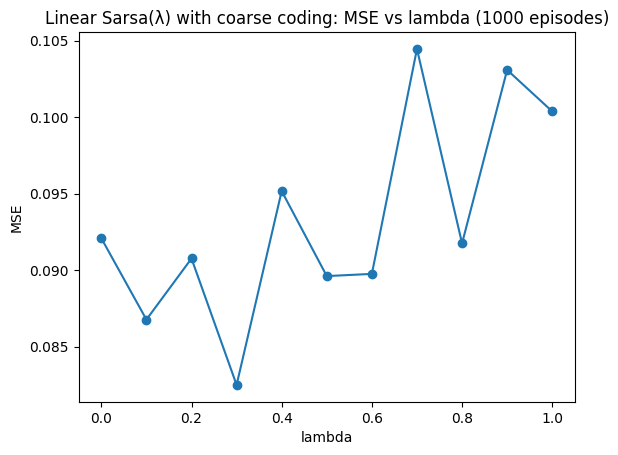

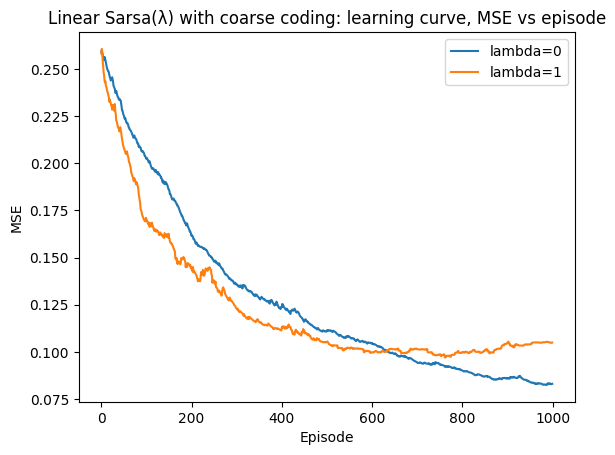

In [10]:
lambdas = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
mse_results = []

for lam in lambdas:
    linear_sarsa = LinearSarsaLambda(lam=lam)
    linear_sarsa.train(1000)
    mse_results.append(compute_mse_linear(linear_sarsa, Q_star))

plt.plot(lambdas, mse_results, marker='o')
plt.xlabel('lambda')
plt.ylabel('MSE')
plt.title('Linear Sarsa(λ) with coarse coding: MSE vs lambda (1000 episodes)')
plt.show()

curve_0 = learning_curve_linear(0, Q_star)
curve_1 = learning_curve_linear(1, Q_star)

plt.plot(range(1000), curve_0, label='lambda=0')
plt.plot(range(1000), curve_1, label='lambda=1')
plt.xlabel('Episode')
plt.ylabel('MSE')
plt.legend()
plt.title('Linear Sarsa(λ) with coarse coding: learning curve, MSE vs episode')
plt.show()


## Discussion

### What are the pros and cons of bootstrapping in Easy21?

Pros of bootstrapping (TD/Sarsa with λ<1):

* Lower variance updates — uses current estimates rather than full returns, so updates are less noisy
* Faster convergence with limited episodes (e.g. λ=0 reaches a low MSE in 1000 episodes vs MC needing far more)
* Can learn online, step-by-step, without waiting for episode termination
* More stable with function approximation than high-λ bootstrapping tends to be

Cons of bootstrapping:

* Introduces bias — early estimates are based on inaccurate Q-values, so updates can propagate errors
* Combined with eligibility traces (high λ) and function approximation, can become unstable
* Requires careful tuning of λ and α to balance the bias-variance tradeoff
* Can converge to suboptimal/degenerate policies if early bootstrapped estimates mislead exploration

### Would you expect bootstrapping to help more in blackjack or Easy21? Why?

Bootstrapping would likely help more in Easy21 than in standard blackjack, for a few reasons:

* Easy21 has a larger effective state space (player sums 1–21 including negative-going states from red
  cards, vs blackjack's bounded 4–21 with simpler dynamics), so episodes can be longer and MC returns
  have higher variance — TD's lower-variance bootstrapped updates help more.
* Easy21's red cards introduce more stochasticity within an episode (the sum can go up or down), making
  full-episode MC returns noisier and harder to attribute to specific (state, action) pairs —
  bootstrapping breaks this into smaller, more tractable updates.
* Standard blackjack has simpler, mostly monotonic dynamics (sums only increase until stick/bust),
  shorter episodes, and a well-structured state space — MC already converges reasonably fast, so the
  relative benefit of bootstrapping is smaller.

### What are the pros and cons of function approximation in Easy21?

Pros:

* Drastically fewer parameters (36 weights vs 420 tabular (s,a) entries) — faster to update and
  generalizes across states
* Generalization — visiting one state updates weights shared with similar/overlapping states (via
  coarse coding), so learning transfers to unvisited or rarely-visited states
* Useful for scaling to larger state/action spaces where tabular methods become infeasible

Cons:

* Introduces approximation bias — the true Q-function may not be representable as a linear combination
  of the chosen features, capping achievable accuracy
* Coarse coding choices (interval boundaries, number of features) significantly affect quality — poor
  feature design limits performance regardless of training
* Combined with high λ and bootstrapping, can be less stable than tabular methods
* Generalization can be a double-edged sword — updates to one state's features also affect overlapping
  states, which can introduce unwanted interference between dissimilar states sharing a feature

### How would you modify the function approximator suggested in this section to get better results in Easy21?

* Finer, less-overlapping intervals — smaller bins for player sum (especially near 21 where bust risk
  is sharp) would reduce approximation bias
* Tile coding with multiple overlapping tilings — instead of one coarse partition, use several offset
  partitions and sum their activations, giving finer effective resolution while retaining generalization
* Add interaction features — e.g. an explicit (player − dealer) difference feature, since the relative
  gap matters more than absolute values
* Non-linear function approximation — a small neural network or polynomial/RBF features could capture
  the non-linear Q-surface (seen in the wireframe plot) better than linear coarse coding
* Adaptive/decaying step-size instead of a fixed α=0.01 — could stabilize high-λ training
* Accumulating vs. replacing traces — replacing eligibility traces often perform better with function
  approximation and can reduce instability at high λ